In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/sanskargupta/Documents/Programming /Projects/Employee Retention Prediction Platform/dataset/EmployeeAttrition&Performance.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# Observation:
The dataset contains no missing values across all features. Therefore, no imputation or removal of records is required before further analysis.

In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
df.shape

(1470, 35)

In [8]:
df.duplicated().sum()

np.int64(0)

# Observation:-
there are no duplicated values

In [9]:
df.nunique().sort_values()

Over18                         1
StandardHours                  1
EmployeeCount                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
MaritalStatus                  3
Department                     3
BusinessTravel                 3
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [10]:
constant_cols = ['Over18','StandardHours','EmployeeCount','EmployeeNumber']
df.drop(columns=constant_cols,inplace=True,axis=1)

In [11]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


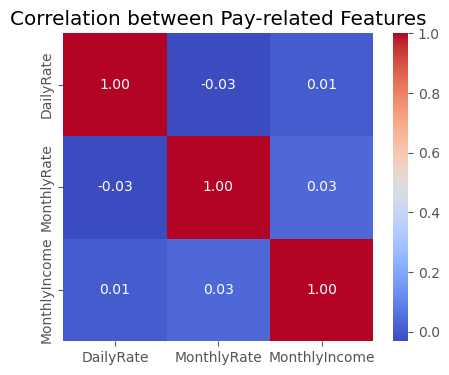

In [12]:
plt.style.use('ggplot')
corr = df[['DailyRate', 'MonthlyRate', 'MonthlyIncome']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Pay-related Features")
plt.show()

# OBSERVATION:-
The pay-related features (DailyRate, MonthlyRate, and MonthlyIncome) 
show negligible linear correlation with one another (all correlation coefficients are close to 0). 
Therefore, these variables appear to capture different aspects of employee compensation and do not exhibit multicollinearity.

In [13]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [14]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

<Axes: xlabel='Attrition', ylabel='count'>

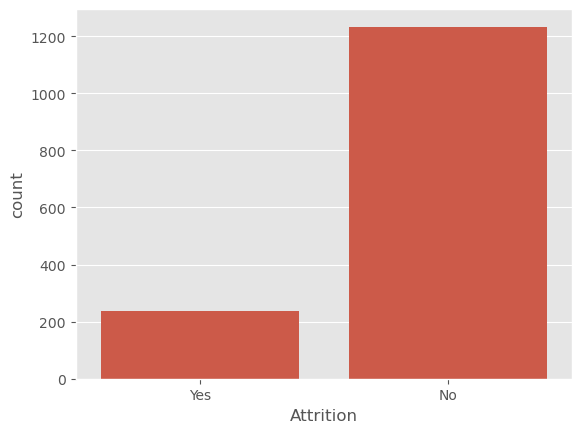

In [15]:
plt.style.use('ggplot')
sns.countplot(x = df['Attrition'])

In [16]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

# Observation
The target variable Attrition is imbalanced. Around 84% of employees stayed with the company (No), while only about 16% left (Yes). This imbalance should be considered during model building, as relying solely on accuracy may be misleading. Metrics such as Precision, Recall, F1-score, and ROC-AUC will provide a more comprehensive evaluation.

In [17]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
Categorical: Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')


# AGE

In [18]:
df['Age'].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

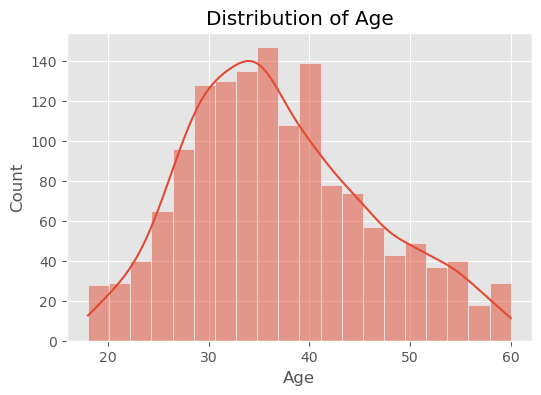

In [19]:
plt.style.use('ggplot')
plt.figure(figsize=(6,4))
sns.histplot(df['Age'],bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

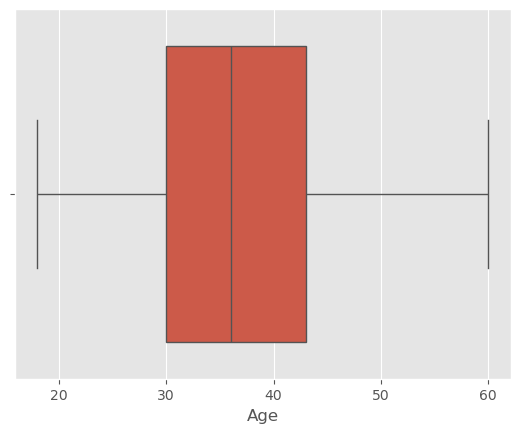

In [20]:
plt.style.use('ggplot')
sns.boxplot(x=df['Age'])
plt.show()

# Observation :-
Most employees are between 30-43 of age.    
    The age distribution is approximately bell-shaped.

# MONTHLY INCOME

In [21]:
df['MonthlyIncome'].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

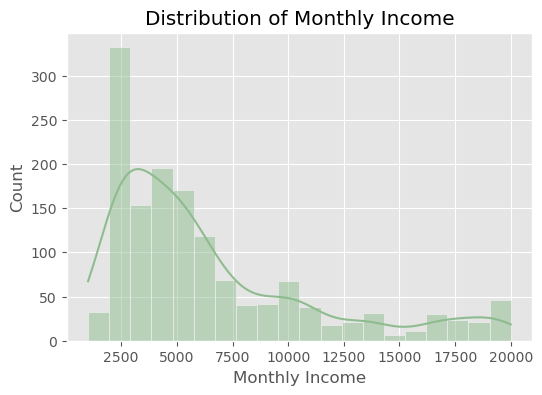

In [22]:
plt.style.use('ggplot')
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyIncome'],bins=20, kde=True, color='darkseagreen')
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.show()

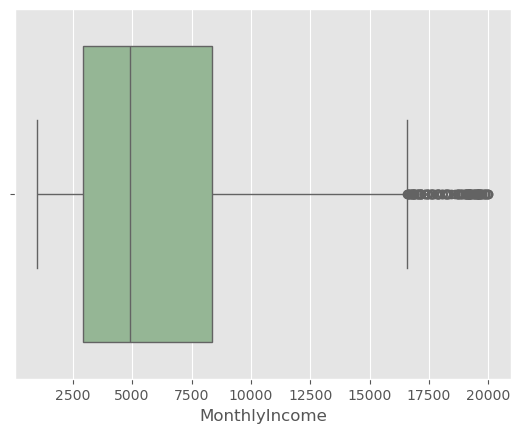

In [23]:
plt.style.use('ggplot')
sns.boxplot(x=df['MonthlyIncome'],color='darkseagreen')
plt.show()

# Observations

1. The distribution of MonthlyIncome is positively (right) skewed.
2. Most employees earn between ₹2,000 and ₹8,000 (dataset units).
3. Only a small number of employees have very high monthly incomes (above ₹15,000).
4. The income distribution is not normally distributed because of the long right tail.
5. The boxplot shows several high-income outliers.
6. These outliers are present only on the upper end of the distribution.
7. The median income lies in the lower half of the income range, indicating that most employees earn relatively lower salaries.

In [24]:
import matplotlib.colors as mcolors

print(mcolors.CSS4_COLORS.keys())

dict_keys(['aliceblue', 'antiquewhite', 'aqua', 'aquamarine', 'azure', 'beige', 'bisque', 'black', 'blanchedalmond', 'blue', 'blueviolet', 'brown', 'burlywood', 'cadetblue', 'chartreuse', 'chocolate', 'coral', 'cornflowerblue', 'cornsilk', 'crimson', 'cyan', 'darkblue', 'darkcyan', 'darkgoldenrod', 'darkgray', 'darkgreen', 'darkgrey', 'darkkhaki', 'darkmagenta', 'darkolivegreen', 'darkorange', 'darkorchid', 'darkred', 'darksalmon', 'darkseagreen', 'darkslateblue', 'darkslategray', 'darkslategrey', 'darkturquoise', 'darkviolet', 'deeppink', 'deepskyblue', 'dimgray', 'dimgrey', 'dodgerblue', 'firebrick', 'floralwhite', 'forestgreen', 'fuchsia', 'gainsboro', 'ghostwhite', 'gold', 'goldenrod', 'gray', 'green', 'greenyellow', 'grey', 'honeydew', 'hotpink', 'indianred', 'indigo', 'ivory', 'khaki', 'lavender', 'lavenderblush', 'lawngreen', 'lemonchiffon', 'lightblue', 'lightcoral', 'lightcyan', 'lightgoldenrodyellow', 'lightgray', 'lightgreen', 'lightgrey', 'lightpink', 'lightsalmon', 'lights

# TOTAL WORKING YEARS

In [25]:
df['TotalWorkingYears'].describe()

count    1470.000000
mean       11.279592
std         7.780782
min         0.000000
25%         6.000000
50%        10.000000
75%        15.000000
max        40.000000
Name: TotalWorkingYears, dtype: float64

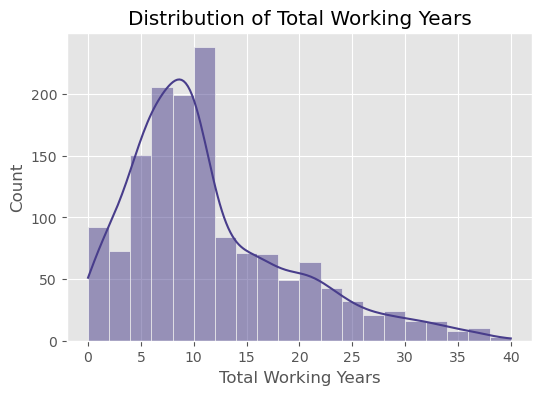

In [26]:
plt.style.use('ggplot')
plt.figure(figsize=(6,4))
sns.histplot(df['TotalWorkingYears'],bins=20, kde=True, color='darkslateblue')
plt.title("Distribution of Total Working Years")
plt.xlabel("Total Working Years")
plt.ylabel("Count")
plt.show()

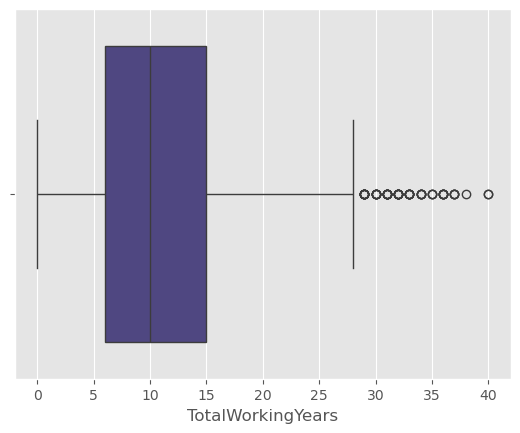

In [27]:
plt.style.use('ggplot')
sns.boxplot(x=df['TotalWorkingYears'],color='darkslateblue')
plt.show()

# Observations

1. The distribution of TotalWorkingYears is positively (right) skewed, with most employees having fewer years of work experience.
2. The highest concentration of employees falls between 5 and 12 years of total work experience.
3. Only a small proportion of employees have more than 25 years of work experience.
4. The distribution is not normally distributed due to the long right tail.
5. The boxplot shows several high-value outliers, primarily for employees with more than 28 years of work experience.
6. These outliers are likely to represent highly experienced or senior employees rather than data errors.
7. The median total working experience is approximately 10 years, indicating that half of the employees have around 10 years or less of experience.
8. Since these observations are realistic, they should be retained for further analysis.

# Distance From Home

In [28]:
df['DistanceFromHome'].describe()

count    1470.000000
mean        9.192517
std         8.106864
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: DistanceFromHome, dtype: float64

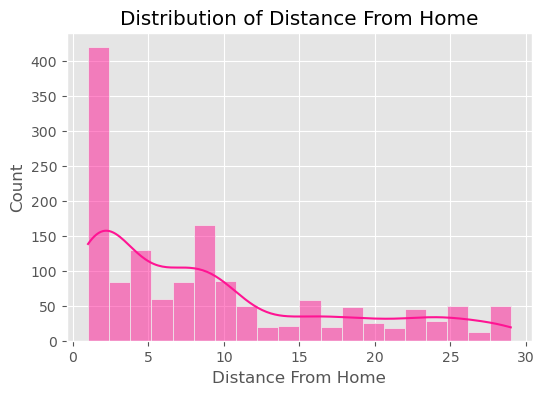

In [29]:
plt.style.use('ggplot')
plt.figure(figsize=(6,4))
sns.histplot(df['DistanceFromHome'],bins=20, kde=True, color='deeppink')
plt.title("Distribution of Distance From Home")
plt.xlabel("Distance From Home")
plt.ylabel("Count")
plt.show()

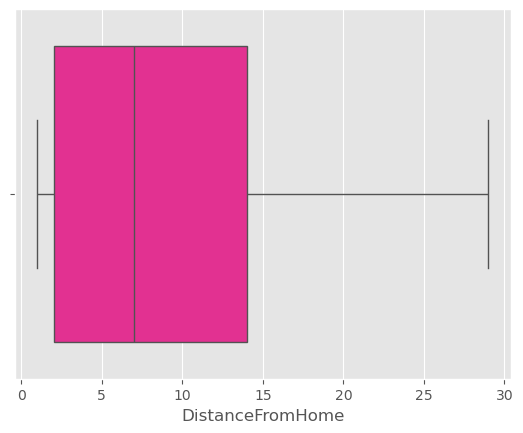

In [30]:
plt.style.use('ggplot')
sns.boxplot(x=df['DistanceFromHome'],color='deeppink')
plt.show()

# Observations 

1. The distribution of DistanceFromHome is positively (right) skewed, with most employees living closer to their workplace.
2. A large number of employees live within 1–5 km of their workplace, as indicated by the highest bars in the histogram.
3. The frequency of employees decreases as the distance from home increases, showing that long-distance commuting is less common.
4. The KDE curve peaks at lower distance values and gradually declines, confirming the right-skewed nature of the distribution.
5. Employees are distributed across a range of 1 km to 29 km, indicating varying commuting distances.
6. There are no distinct multiple peaks (multimodality), suggesting a single dominant distribution.
7. No obvious gaps or unusual spikes are observed, indicating a relatively continuous distribution of commuting distances.

# CATEGORIAL FEATURES

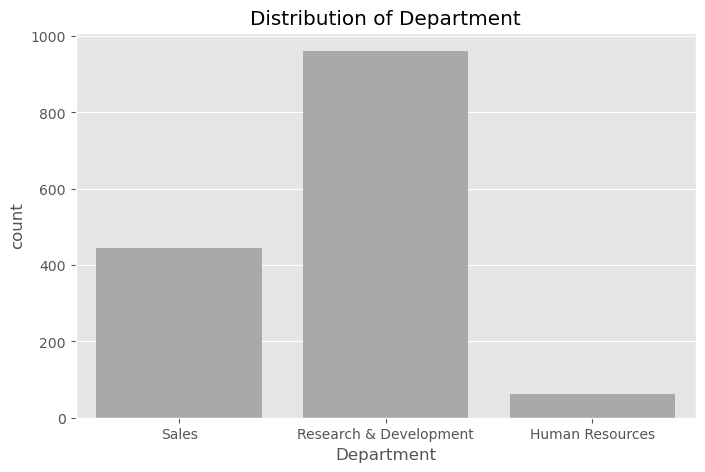

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x="Department", data=df,color='darkgray')
plt.title("Distribution of Department")
plt.show()

# Observations:

* Research & Development has the highest number of employees.
* Sales is the second-largest department.
* Human Resources has the fewest employees.

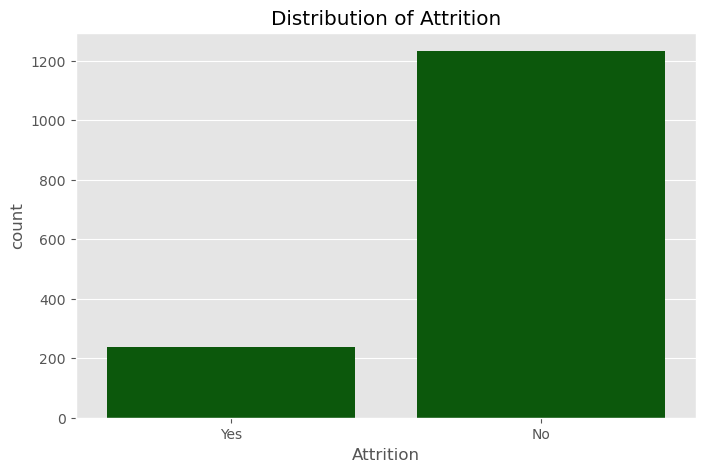

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x="Attrition", data=df,color='darkgreen')
plt.title("Distribution of Attrition")
plt.show()

# Observations:

* The majority of employees have not left the company.
* The dataset is imbalanced, with employees who stayed significantly outnumbering those who left.
* Approximately 16% of employees experienced attrition.

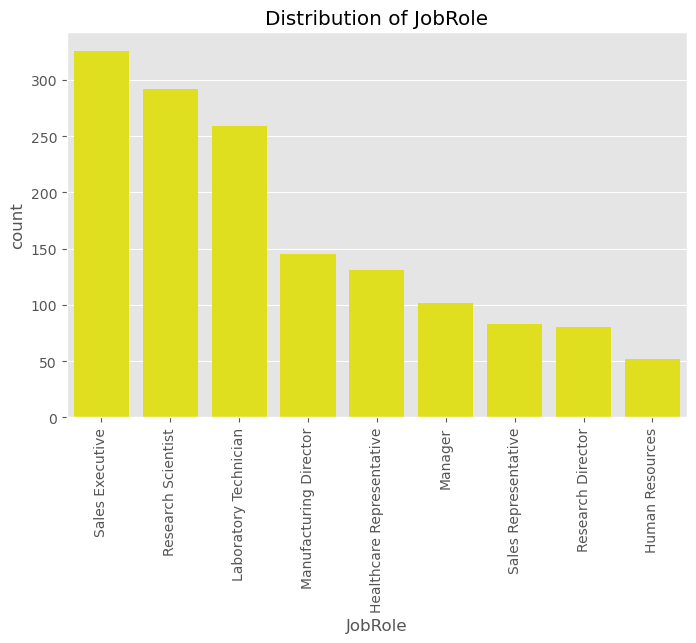

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x="JobRole", data=df,color='yellow')
plt.xticks(rotation = 90)
plt.title("Distribution of JobRole")
plt.show()

# Observations:

* Sales Executives and Research Scientists are among the most common job roles.
* Human Resources and Research Directors have relatively fewer employees.
* The distribution of employees varies considerably across different job roles.

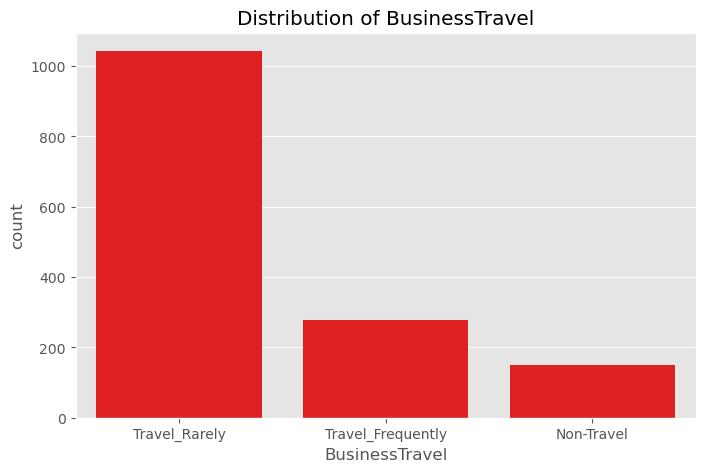

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x="BusinessTravel", data=df,color='red')
plt.title("Distribution of BusinessTravel")
plt.show()

# Observations:

* Most employees travel rarely for work.
* A smaller proportion travel frequently.
* Very few employees do not travel at all.

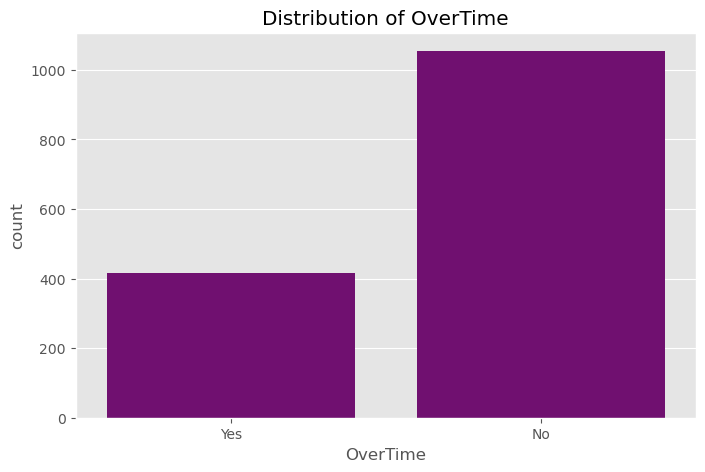

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(x="OverTime", data=df,color='purple')
plt.title("Distribution of OverTime")
plt.show()

# Observations:

* Most employees do not work overtime.
* A smaller proportion of employees work overtime.
* Overtime may influence employee attrition and will be examined further during bivariate analysis.

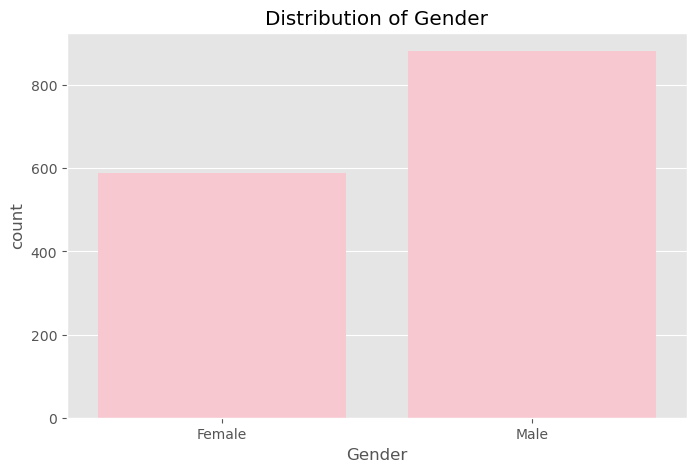

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x="Gender", data=df,color='pink')
plt.title("Distribution of Gender")
plt.show()



# Observations:

* The workforce consists of both male and female employees.
* Male employees slightly outnumber female employees.
* The gender distribution is relatively balanced.

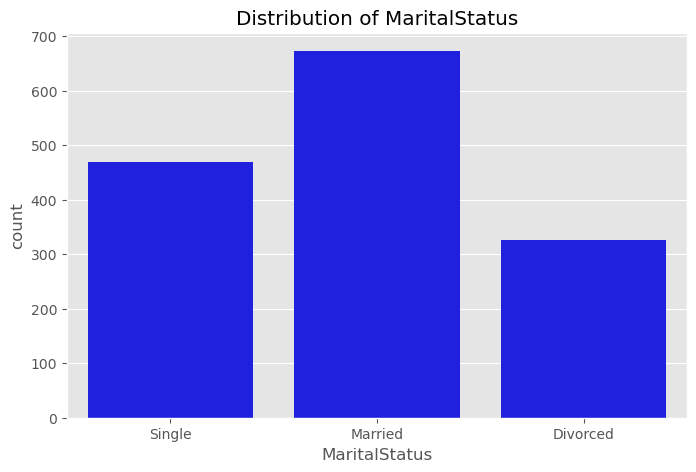

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(x="MaritalStatus", data=df,color='blue')
plt.title("Distribution of MaritalStatus")
plt.show()

# Observations:

* Married employees form the largest group.
* Single employees are the second-largest group.
* Divorced employees make up the smallest proportion.

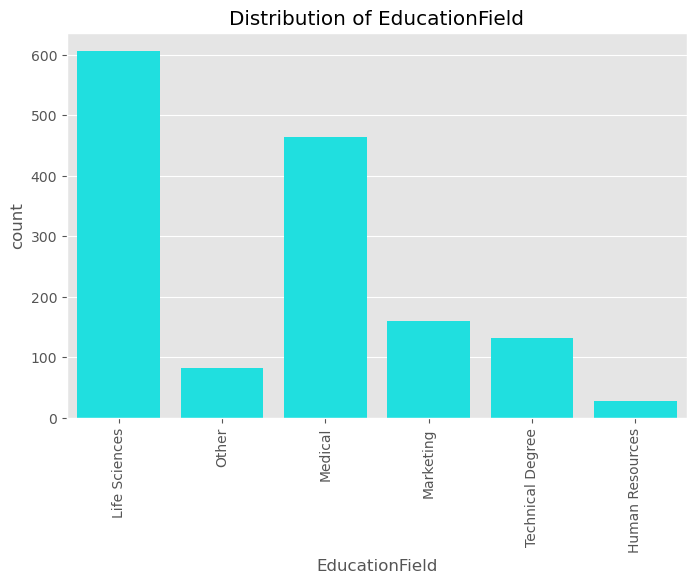

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x="EducationField", data=df,color='cyan')
plt.title("Distribution of EducationField")
plt.xticks(rotation = 90)
plt.show()

# Observations:

* Life Sciences has the highest number of employees.
* Medical is the second most common education field.
* Human Resources has the fewest employees.

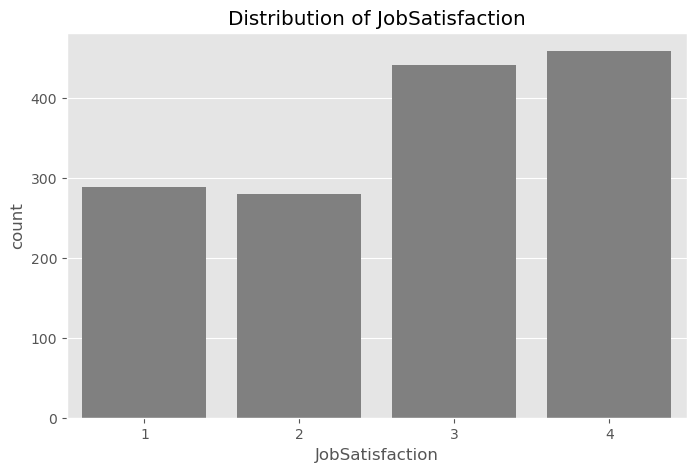

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(x="JobSatisfaction", data=df,color='grey')
plt.title("Distribution of JobSatisfaction")
plt.show()

# Observations:

* Employees are distributed across all satisfaction levels.
* No single satisfaction level overwhelmingly dominates the dataset.
* The relationship between job satisfaction and attrition should be explored further.

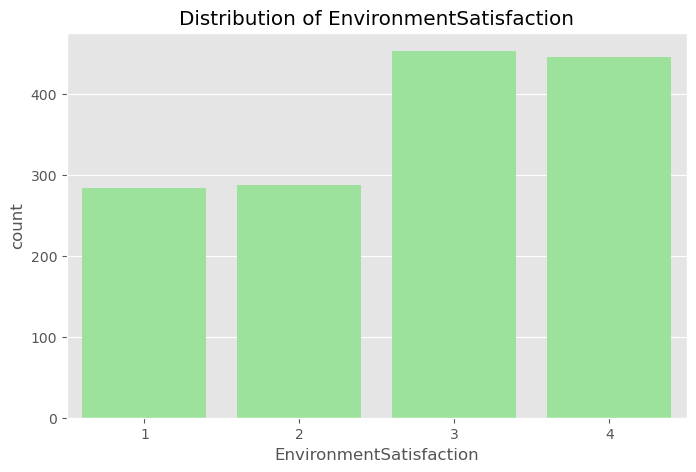

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(x="EnvironmentSatisfaction", data=df,color='lightgreen')
plt.title("Distribution of EnvironmentSatisfaction")
plt.show()

# Observations:

* Employees are represented across all levels of environment satisfaction.
* Most employees report medium to high satisfaction.
* This feature may influence employee retention.

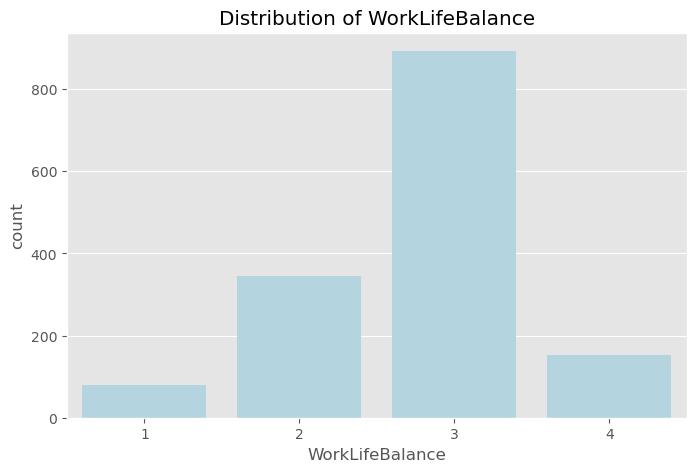

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(x="WorkLifeBalance", data=df,color='lightblue')
plt.title("Distribution of WorkLifeBalance")
plt.show()

# Observations:

* Most employees report a good work-life balance.
* Very few employees report poor work-life balance.
* Work-life balance may be an important factor affecting employee retention.

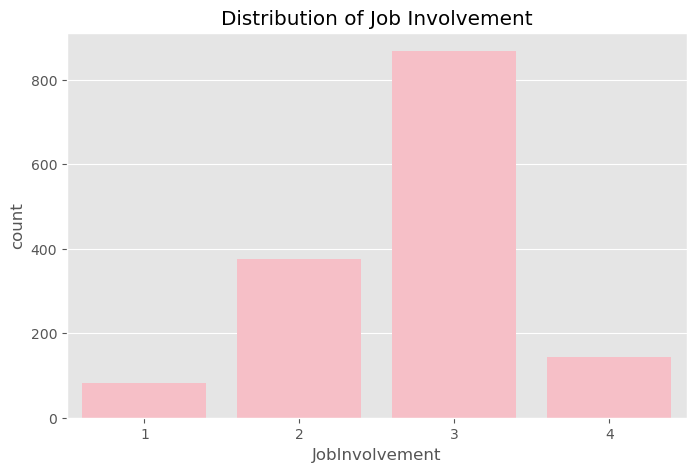

In [42]:
plt.figure(figsize=(8,5))
sns.countplot(x="JobInvolvement", data=df,color='lightpink')
plt.title("Distribution of Job Involvement")
plt.show()

# Observations:

* Most employees have moderate to high job involvement.
* Very few employees report the lowest level of involvement.
* Higher involvement may be associated with lower attrition.

# BIVARIATE ANALYSIS

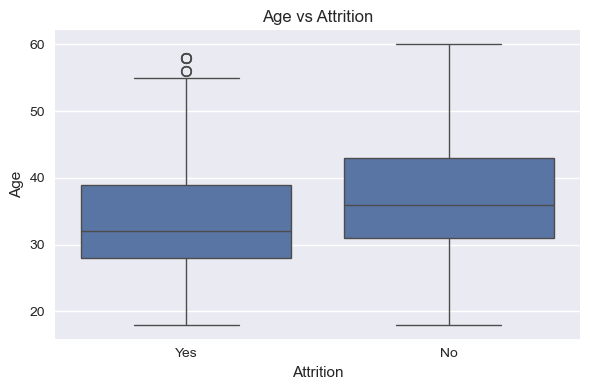

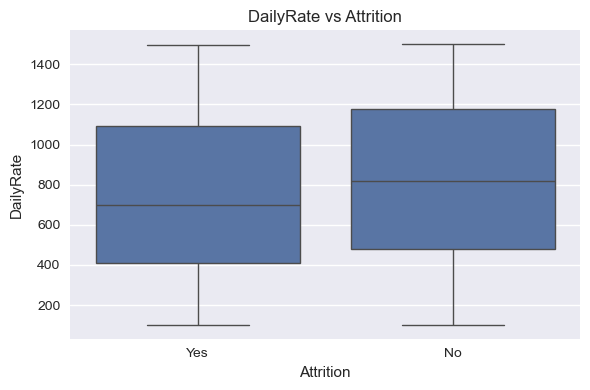

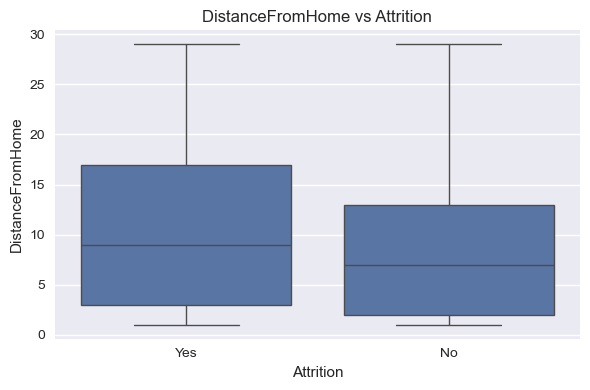

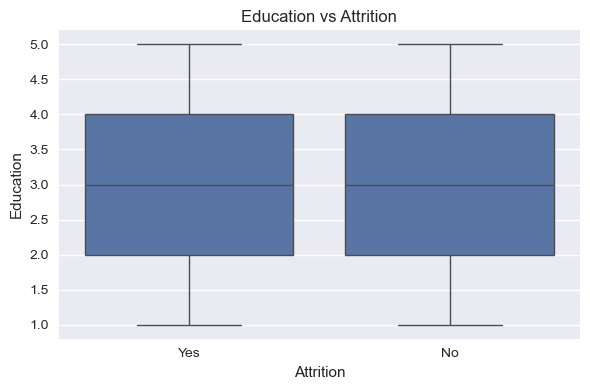

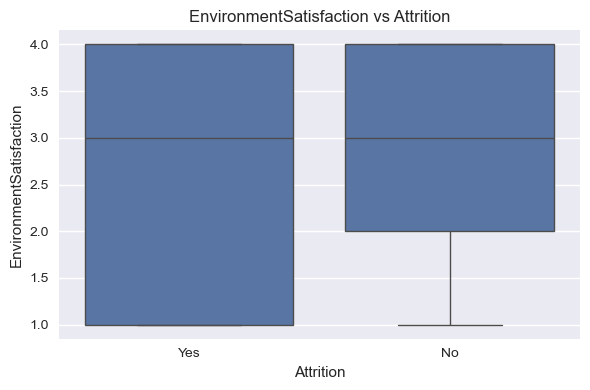

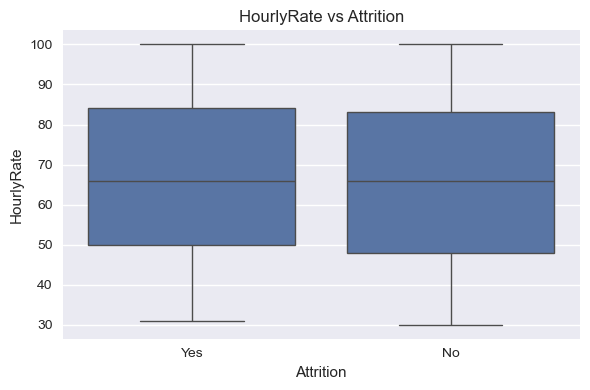

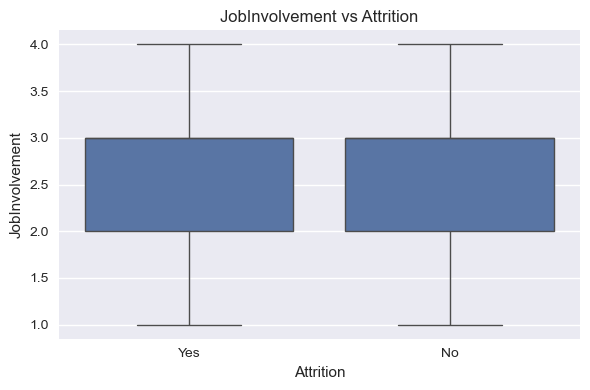

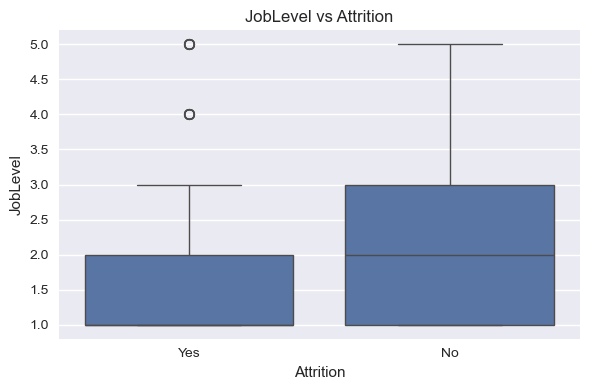

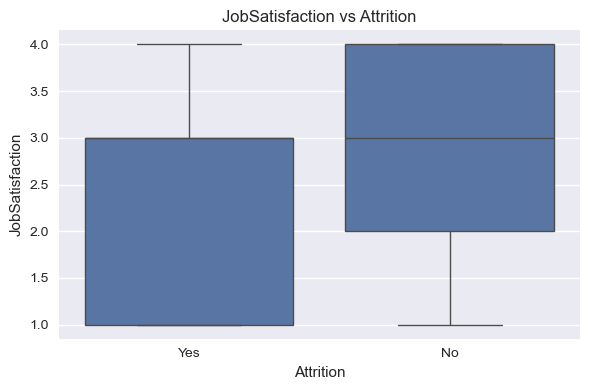

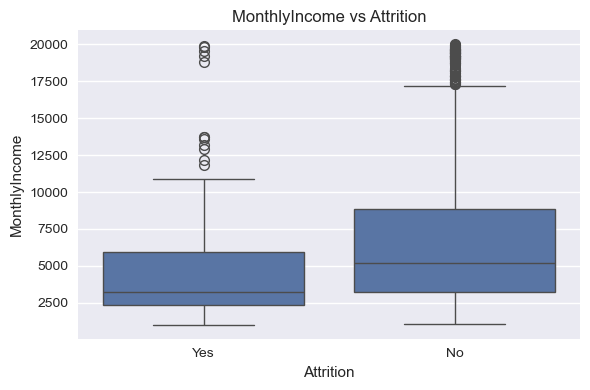

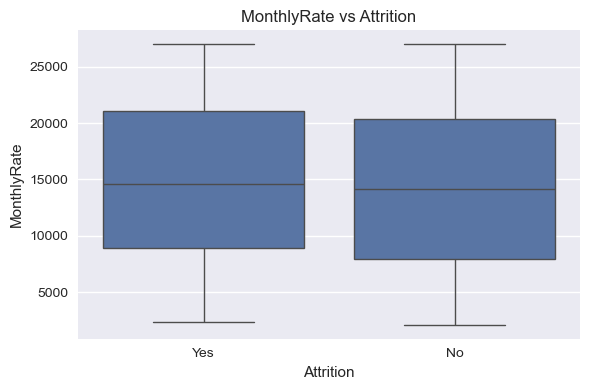

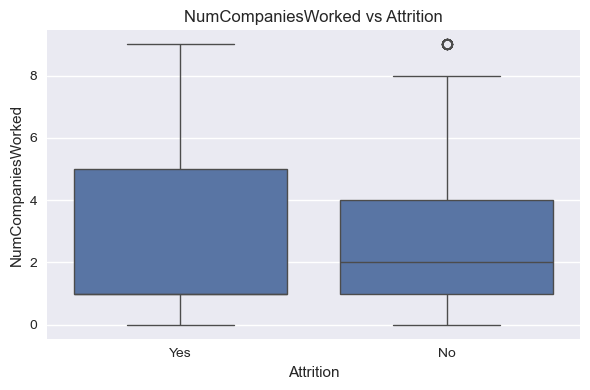

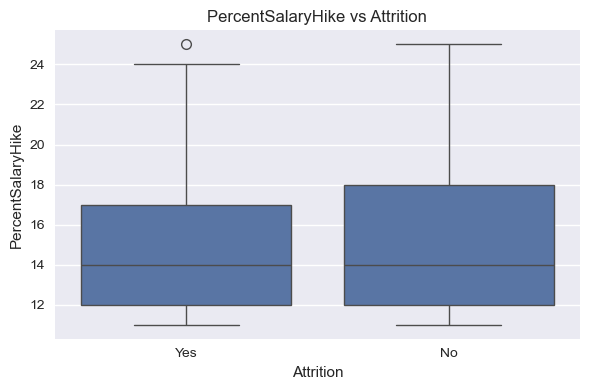

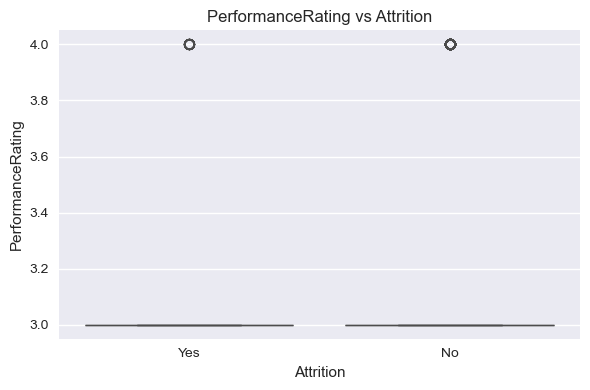

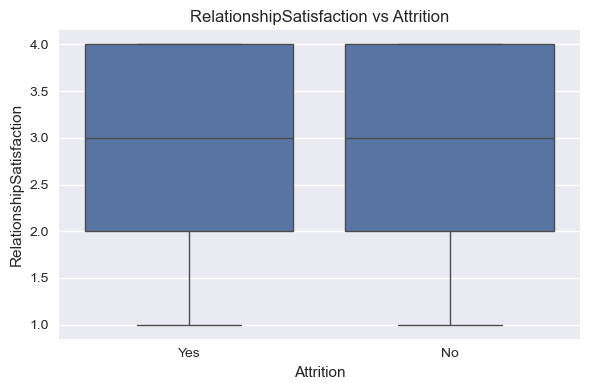

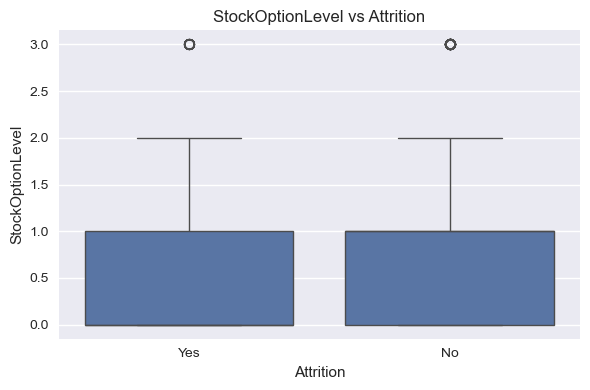

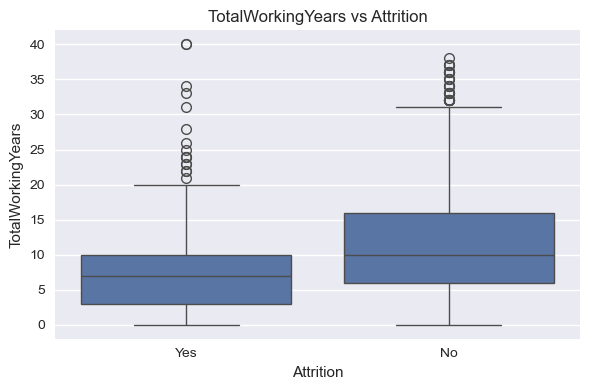

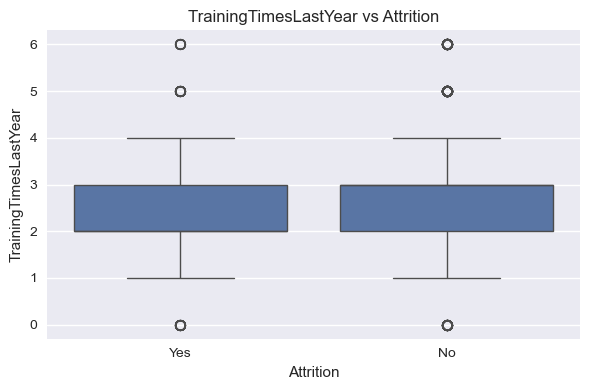

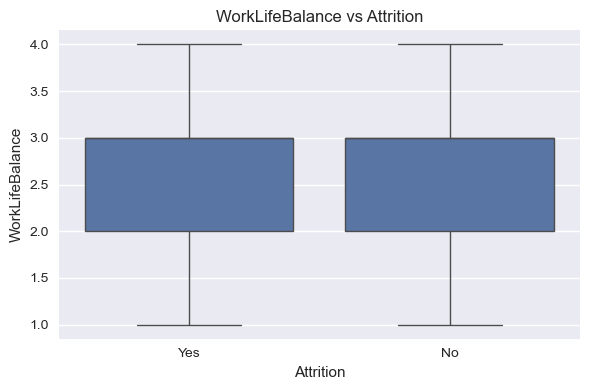

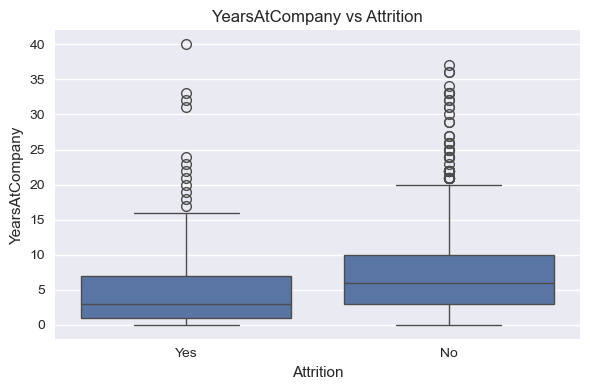

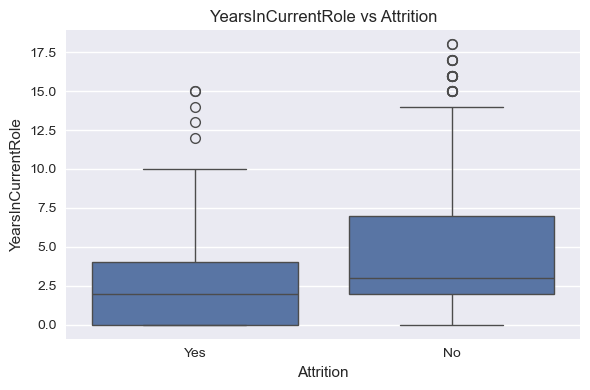

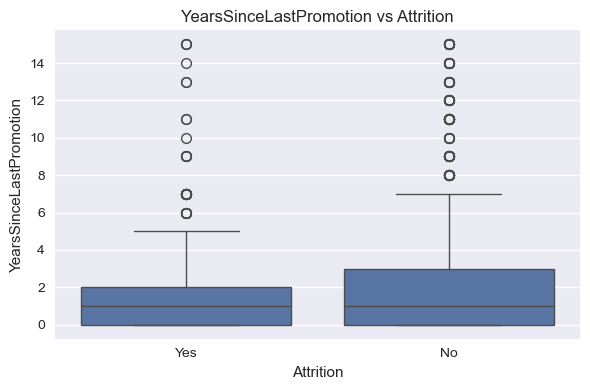

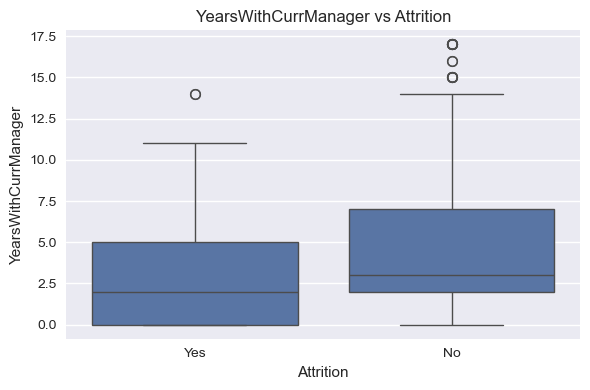

In [43]:
plt.style.use('seaborn-v0_8')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(f'{col} vs Attrition')
    plt.tight_layout()
    plt.show()

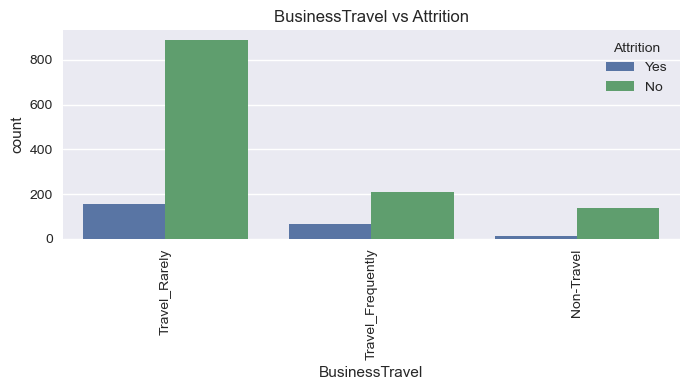

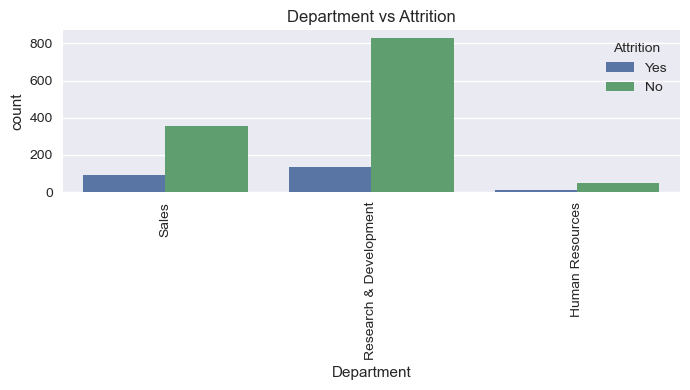

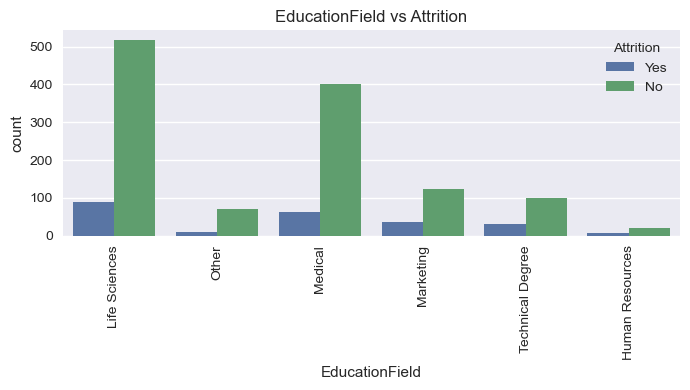

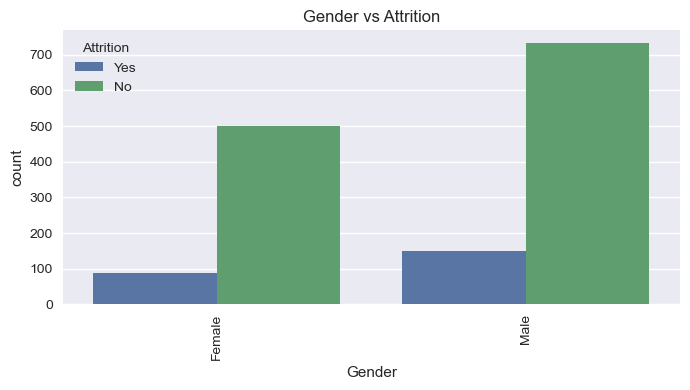

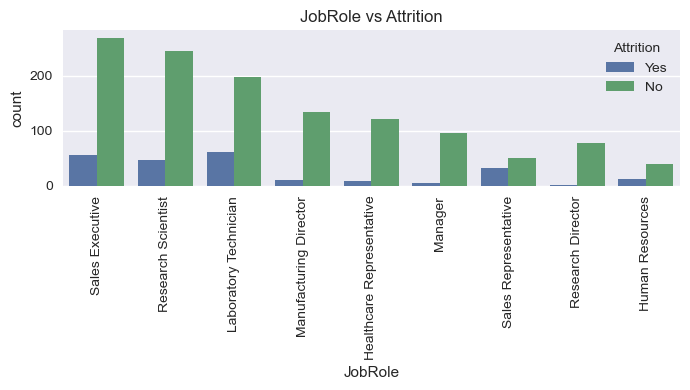

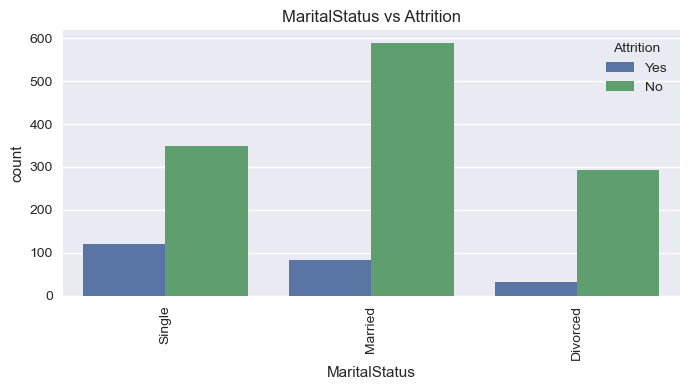

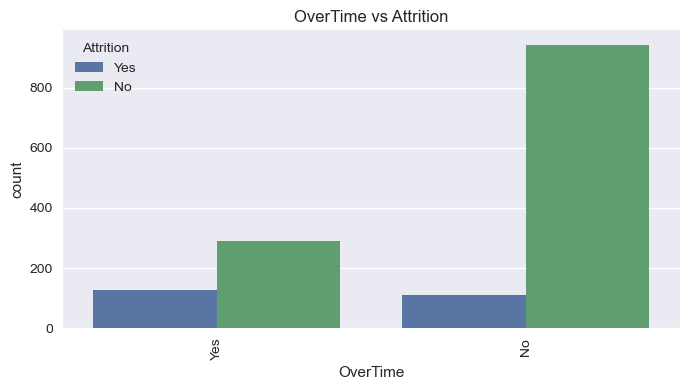

In [44]:
plt.style.use('seaborn-v0_8')
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = [col for col in categorical_cols if col != 'Attrition']
for col in categorical_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Attrition', data=df)
    plt.xticks(rotation=90)
    plt.title(f'{col} vs Attrition')
    plt.tight_layout()
    plt.show()

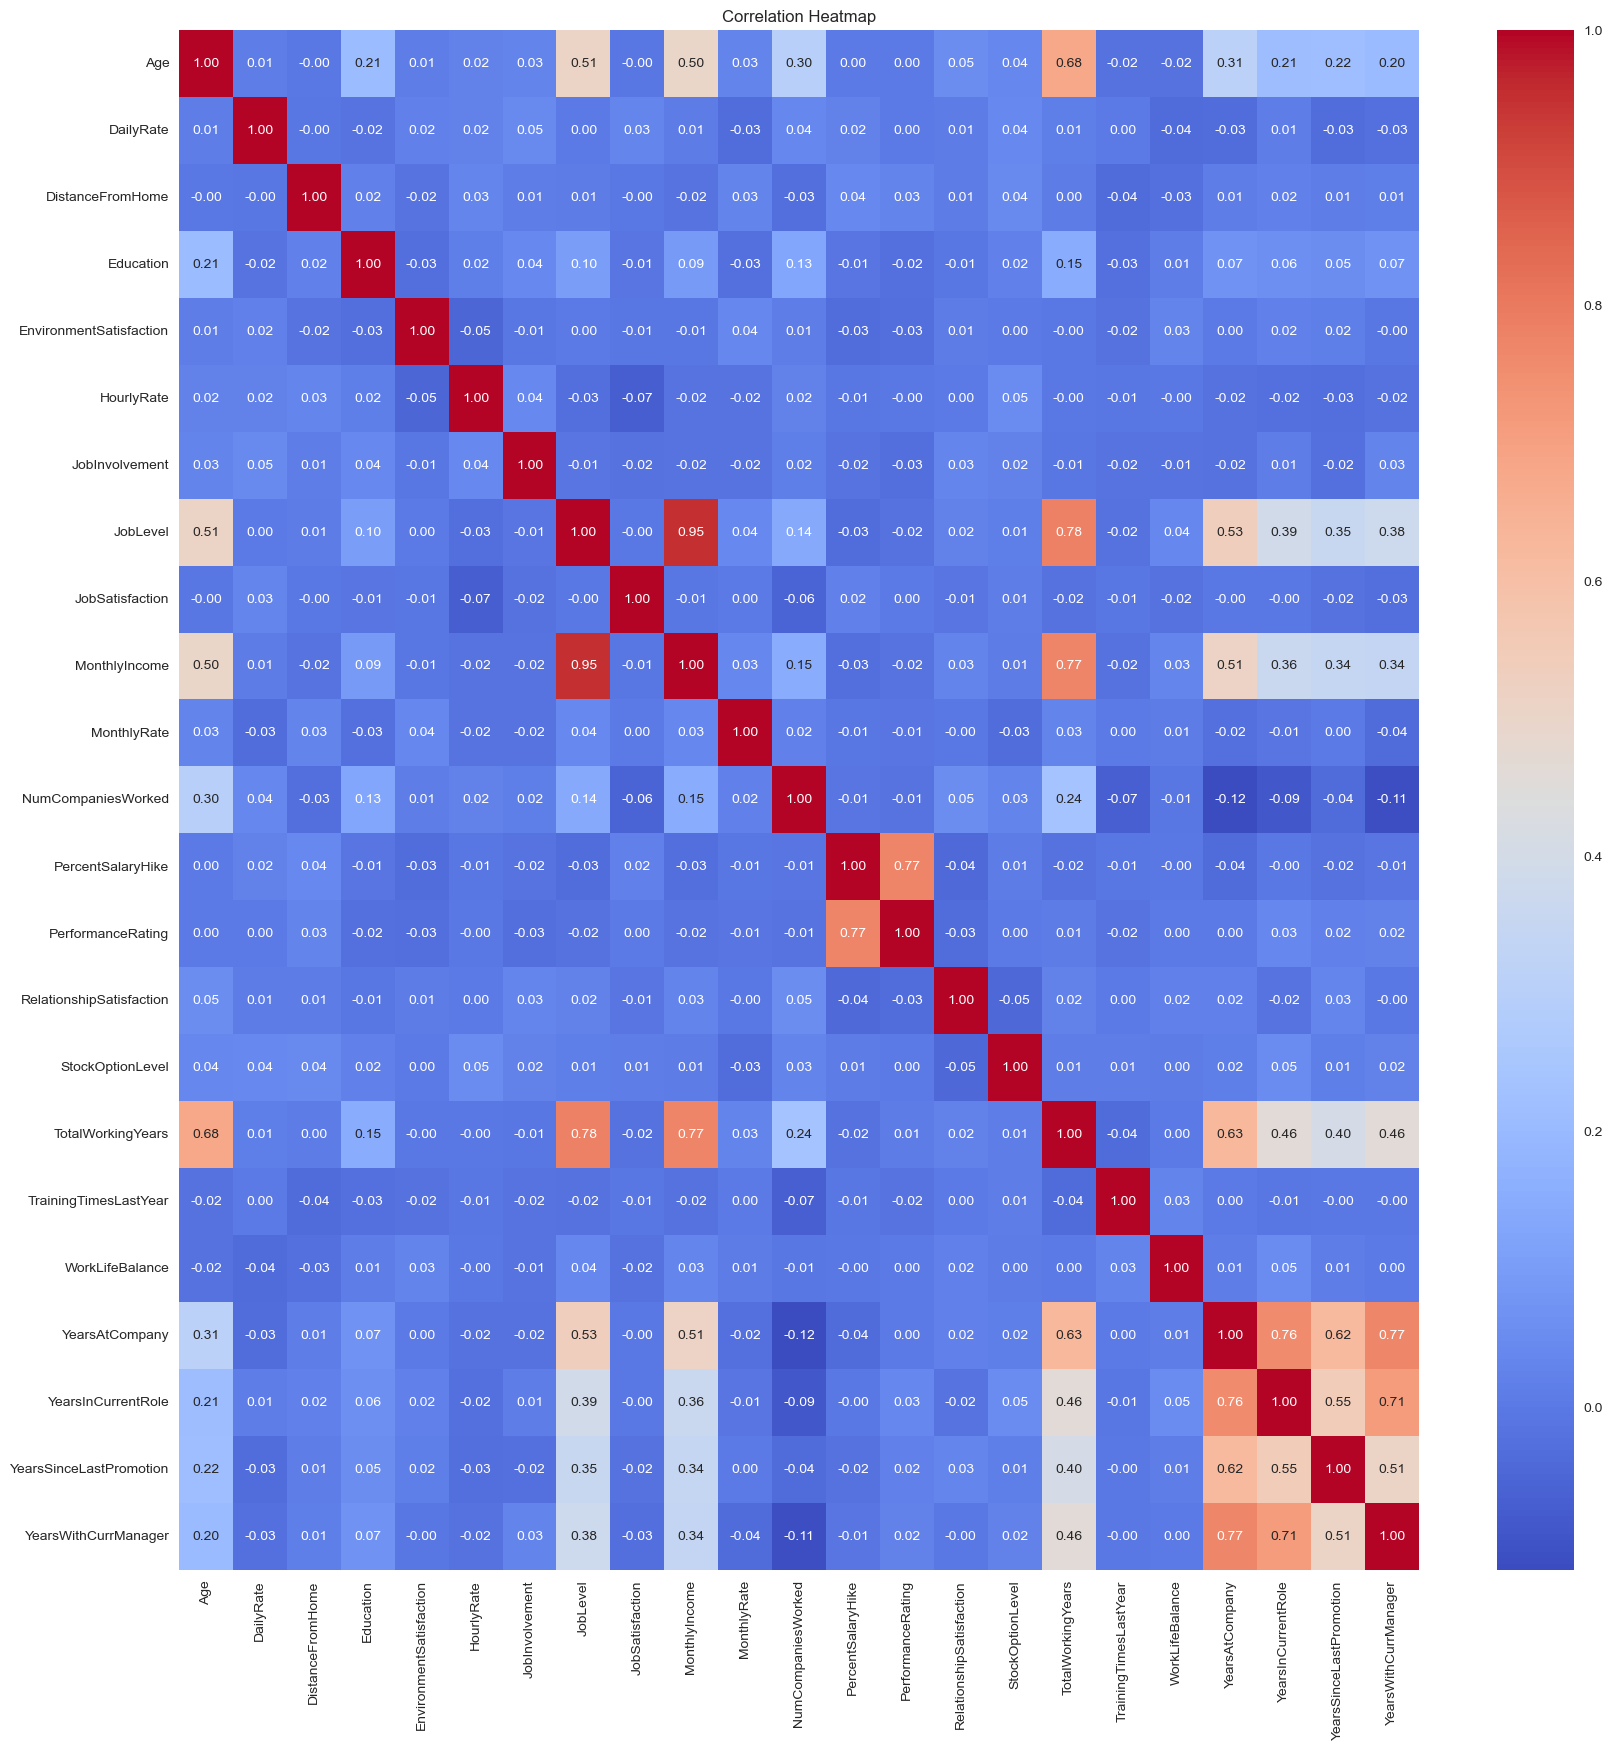

In [45]:
# CORRELATION
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# EDA Summary

* The dataset contains 1,470 employees and 35 features.
* No missing values or duplicate records were found.
* EmployeeCount, EmployeeNumber, StandardHours, and Over18 were removed because they were either constant or identifiers.
* The target variable Attrition is imbalanced, with approximately 84% of employees staying and 16% leaving.
* Most numerical features are right-skewed and contain genuine high-value outliers.
* The correlation heatmap shows no severe multicollinearity among most numerical features.
* Several features, such as OverTime, MonthlyIncome, TotalWorkingYears, and YearsAtCompany, appear likely to influence employee attrition and will be explored further during model training.

In [46]:
df.to_csv('/Users/sanskargupta/Documents/Programming /Projects/Employee Retention Prediction Platform/dataset/hr_attrition_cleaned.csv',index=True)